# Portfolio Optimization with QUBO + QAOA

This notebook builds a **binary portfolio-selection** QUBO, uses a **scaled slack-variable encoding** for the budget inequality, compares **COBYLA / Nelder-Mead / Powell**, plots all cost histories on one graph, samples from the best solver, and validates against a classical brute-force optimum.


In [2]:
import time
from IPython import get_ipython

start_time = None

def pre_run_cell(info):
    global start_time
    start_time = time.time()

def post_run_cell(result):
    global start_time
    if start_time is not None:
        end_time = time.time()
        print(f"⏱️ Execution time: {end_time - start_time:.4f} seconds")

ip = get_ipython()
ip.events.register('pre_run_cell', pre_run_cell)
ip.events.register('post_run_cell', post_run_cell)

In [3]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product
from types import SimpleNamespace
from scipy.optimize import minimize

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.primitives import StatevectorEstimator
from qiskit_algorithms.optimizers import COBYLA
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.converters import QuadraticProgramToQubo
from qiskit_optimization.translators import to_ising


⏱️ Execution time: 3.1660 seconds


## 1) Input portfolio data

You can replace the table below with your own list of companies.  
The notebook is written so you can increase the number of companies more easily by **scaling the budget** before building the slack register.


In [5]:

data = {
    "Company": ["TCS", "INFOSYS", "RELIANCE", "MINDTREE", "BERGEPAINT", "BHARTI AIRTEL",
                "SANATHAN TEXTILES", "FUSION FINANCE", "TIME TECHNO","IBM","Quera","IONQ"],
    "Allocation (₹)": [300000, 100000, 500000, 180000, 150000, 150000, 120000, 90000, 100000,200000,160000,250000],
    "Upside %": [2, 6, 1, 4.5, 3, 9, 9.5, 11, 3,4,5,2.5],
}

df = pd.DataFrame(data)
budget = 800000
n = len(df)

display(df)
print("Budget (₹):", budget)
print("Number of companies:", n)


,Company,Allocation (₹),Upside %
0,TCS,300000,2.0
1,INFOSYS,100000,6.0
2,RELIANCE,500000,1.0
3,MINDTREE,180000,4.5
4,BERGEPAINT,150000,3.0
5,BHARTI AIRTEL,150000,9.0
6,SANATHAN TEXTILES,120000,9.5
7,FUSION FINANCE,90000,11.0
8,TIME TECHNO,100000,3.0
9,IBM,200000,4.0


Budget (₹): 800000
Number of companies: 12
⏱️ Execution time: 0.0349 seconds


## 2) Scale the budget before introducing slack variables

Why scale?  
If you encode the unused budget directly in rupees, then with `budget = 800000` you need about `ceil(log2(800000)) = 20` slack bits.  
That becomes expensive very quickly.

Here we use a **chunk size** of `₹50,000`, so:
- `budget_units = 800000 / 50000 = 16`
- slack bits = `ceil(log2(16 + 1)) = 5`

This is much smaller than 20 slack qubits.


In [7]:

scale = 50000  # each unit = ₹50,000

df["Allocation_units"] = (df["Allocation (₹)"] / scale).round().astype(int)
budget_units = int(round(budget / scale))

alloc_units = df["Allocation_units"].to_numpy(dtype=int)
upside_values_rupees = (df["Allocation (₹)"] * df["Upside %"] / 100.0).to_numpy()
allocations_rupees = df["Allocation (₹)"].to_numpy()

display(df)
print("Scale (₹ per unit):", scale)
print("Budget in scaled units:", budget_units)
print("Allocation units:", alloc_units.tolist())


,Company,Allocation (₹),Upside %,Allocation_units
0,TCS,300000,2.0,6
1,INFOSYS,100000,6.0,2
2,RELIANCE,500000,1.0,10
3,MINDTREE,180000,4.5,4
4,BERGEPAINT,150000,3.0,3
5,BHARTI AIRTEL,150000,9.0,3
6,SANATHAN TEXTILES,120000,9.5,2
7,FUSION FINANCE,90000,11.0,2
8,TIME TECHNO,100000,3.0,2
9,IBM,200000,4.0,4


Scale (₹ per unit): 50000
Budget in scaled units: 16
Allocation units: [6, 2, 10, 4, 3, 3, 2, 2, 2, 4, 3, 5]
⏱️ Execution time: 0.0189 seconds


## 3) Build the QUBO with slack variables

We want:

\[
\sum_i a_i x_i \le B
\]

QUBO does not directly support `<=`, so we encode:

\[
\sum_i a_i x_i + s = B
\]

where `s` is the unused budget, represented in binary using extra slack bits.


In [9]:

qp = QuadraticProgram()

# Portfolio decision variables
for i in range(n):
    qp.binary_var(name=f"x{i}")

# Slack register: s = sum_k 2^k s_k
m = int(np.ceil(np.log2(budget_units + 1)))
for k in range(m):
    qp.binary_var(name=f"s{k}")

slack_weights = np.array([2**k for k in range(m)], dtype=int)

# Real objective: maximize expected upside value in ₹
# QUBO is set up as a minimization, so negate it.
objective = {
    f"x{i}": -float(df.loc[i, "Allocation (₹)"] * df.loc[i, "Upside %"] / 100.0)
    for i in range(n)
}

# Penalty term: P * (sum_i a_i x_i + sum_k w_k s_k - B)^2
P = 100.0

quad = {}

# x_i x_j terms
for i in range(n):
    for j in range(n):
        coeff = P * alloc_units[i] * alloc_units[j]
        quad[(f"x{i}", f"x{j}")] = quad.get((f"x{i}", f"x{j}"), 0.0) + coeff

# s_k s_l terms
for k in range(m):
    for l in range(m):
        coeff = P * slack_weights[k] * slack_weights[l]
        quad[(f"s{k}", f"s{l}")] = quad.get((f"s{k}", f"s{l}"), 0.0) + coeff

# x_i s_k cross terms
for i in range(n):
    for k in range(m):
        coeff = 2.0 * P * alloc_units[i] * slack_weights[k]
        quad[(f"x{i}", f"s{k}")] = quad.get((f"x{i}", f"s{k}"), 0.0) + coeff

# Linear terms from -2 * P * B * (sum_i a_i x_i + sum_k w_k s_k)
linear_penalty = {
    f"x{i}": -2.0 * P * budget_units * alloc_units[i]
    for i in range(n)
}
for k in range(m):
    linear_penalty[f"s{k}"] = -2.0 * P * budget_units * slack_weights[k]

constant_penalty = P * (budget_units ** 2)

final_linear = {}
for i in range(n):
    final_linear[f"x{i}"] = objective[f"x{i}"] + linear_penalty[f"x{i}"]
for k in range(m):
    final_linear[f"s{k}"] = linear_penalty[f"s{k}"]

qp.minimize(linear=final_linear, quadratic=quad, constant=constant_penalty)
qubo = QuadraticProgramToQubo().convert(qp)

print("Slack bits:", m)
print("Total QUBO variables:", qubo.get_num_vars())
print(qubo.prettyprint())


Slack bits: 5
Total QUBO variables: 17
Problem name: 

Minimize
  100*s0^2 + 400*s0*s1 + 800*s0*s2 + 1600*s0*s3 + 3200*s0*s4 + 400*s1^2
  + 1600*s1*s2 + 3200*s1*s3 + 6400*s1*s4 + 1600*s2^2 + 6400*s2*s3 + 12800*s2*s4
  + 6400*s3^2 + 25600*s3*s4 + 25600*s4^2 + 1200*x0*s0 + 2400*x0*s1 + 4800*x0*s2
  + 9600*x0*s3 + 19200*x0*s4 + 3600*x0^2 + 2400*x0*x1 + 3600*x0*x10
  + 6000*x0*x11 + 12000*x0*x2 + 4800*x0*x3 + 3600*x0*x4 + 3600*x0*x5
  + 2400*x0*x6 + 2400*x0*x7 + 2400*x0*x8 + 4800*x0*x9 + 400*x1*s0 + 800*x1*s1
  + 1600*x1*s2 + 3200*x1*s3 + 6400*x1*s4 + 400*x1^2 + 1200*x1*x10 + 2000*x1*x11
  + 4000*x1*x2 + 1600*x1*x3 + 1200*x1*x4 + 1200*x1*x5 + 800*x1*x6 + 800*x1*x7
  + 800*x1*x8 + 1600*x1*x9 + 600*x10*s0 + 1200*x10*s1 + 2400*x10*s2
  + 4800*x10*s3 + 9600*x10*s4 + 900*x10^2 + 3000*x10*x11 + 1000*x11*s0
  + 2000*x11*s1 + 4000*x11*s2 + 8000*x11*s3 + 16000*x11*s4 + 2500*x11^2
  + 2000*x2*s0 + 4000*x2*s1 + 8000*x2*s2 + 16000*x2*s3 + 32000*x2*s4
  + 6000*x2*x10 + 10000*x2*x11 + 10000*x2^2 + 8000*

## 4) Convert QUBO to Ising Hamiltonian

In [11]:

qubo_matrix = qubo.objective.quadratic.to_array()
linear = qubo.objective.linear.to_array()
constant = qubo.objective.constant
num_total_vars = qubo.get_num_vars()

cost_hamiltonian, offset = to_ising(qubo)
num_qubits = cost_hamiltonian.num_qubits

print("QUBO matrix shape:", qubo_matrix.shape)
print("Linear vector shape:", linear.shape)
print("QUBO constant:", constant)
print("Ising offset:", offset)
print("Number of qubits:", num_qubits)


QUBO matrix shape: (17, 17)
Linear vector shape: (17,)
QUBO constant: 25600.0
Ising offset: 20225.0
Number of qubits: 17
⏱️ Execution time: 0.0871 seconds


## 5) Build a p=1 QAOA circuit

In [13]:

def build_qaoa_circuit(gamma, beta):
    qc = QuantumCircuit(num_qubits)
    qc.h(range(num_qubits))

    # Apply e^{-i gamma H_C} term by term
    for pauli, coeff in zip(cost_hamiltonian.paulis, cost_hamiltonian.coeffs):
        label = pauli.to_label()
        z_indices = [i for i, c in enumerate(label) if c == "Z"]

        angle = -2.0 * gamma * float(np.real(coeff))

        if len(z_indices) == 1:
            qc.rz(angle, z_indices[0])

        elif len(z_indices) == 2:
            i, j = z_indices
            qc.cx(i, j)
            qc.rz(angle, j)
            qc.cx(i, j)

    # Mixer
    for q in range(num_qubits):
        qc.rx(2.0 * beta, q)

    return qc

estimator = StatevectorEstimator()

def qaoa_cost_tracking(params, history_container=None):
    gamma, beta = params
    qc = build_qaoa_circuit(gamma, beta)
    result = estimator.run([(qc, cost_hamiltonian)]).result()
    expectation = result[0].data.evs
    value = float(np.real(expectation))
    if history_container is not None:
        history_container.append(value)
    return value


⏱️ Execution time: 0.0113 seconds


## 6) Run multiple classical optimizers and pick the best one

In [15]:

initial_point = np.array([0.5, 0.5], dtype=float)
maxiter = 100

all_optimizer_runs = {}

# COBYLA
cobyla_history = []
cobyla_optimizer = COBYLA(maxiter=maxiter)
cobyla_result = cobyla_optimizer.minimize(
    fun=lambda x: qaoa_cost_tracking(x, cobyla_history),
    x0=initial_point,
)
all_optimizer_runs["COBYLA"] = {
    "x": np.array(cobyla_result.x, dtype=float),
    "fun": float(cobyla_result.fun),
    "history": cobyla_history,
    "success": True,
    "message": "Completed",
}

# # SciPy solvers
# for method in ["Nelder-Mead", "Powell"]:
#     history = []
#     result = minimize(
#         fun=lambda x, hist=history: qaoa_cost_tracking(x, hist),
#         x0=initial_point,
#         method=method,
#         options={"maxiter": maxiter},
#     )
#     all_optimizer_runs[method] = {
#         "x": np.array(result.x, dtype=float),
#         "fun": float(result.fun),
#         "history": history,
#         "success": bool(result.success),
#         "message": str(result.message),
#     }

comparison_rows = []
for name, res in all_optimizer_runs.items():
    comparison_rows.append({
        "optimizer": name,
        "best_gamma": float(res["x"][0]),
        "best_beta": float(res["x"][1]),
        "best_gamma_wrapped": float(np.mod(res["x"][0], 2 * np.pi)),
        "best_beta_wrapped": float(np.mod(res["x"][1], 2 * np.pi)),
        "minimum_expected_ising_cost": float(res["fun"]),
        "n_function_evals": int(len(res["history"])),
        "success": bool(res["success"]),
        "message": str(res["message"]),
    })

optimizer_results_df = pd.DataFrame(comparison_rows).sort_values(
    "minimum_expected_ising_cost", ascending=True
).reset_index(drop=True)

best_solver_name = optimizer_results_df.loc[0, "optimizer"]
best_run = all_optimizer_runs[best_solver_name]
best_params = best_run["x"]
best_params_wrapped = np.mod(best_params, 2 * np.pi)
best_cost = best_run["fun"]
cost_history = best_run["history"]

results = SimpleNamespace(x=best_params, fun=best_cost, method=best_solver_name)

display(optimizer_results_df)
print("Best solver:", best_solver_name)
print("Best gamma, beta:", best_params)
print("Wrapped best gamma, beta:", best_params_wrapped)
print("Minimum expected Ising cost:", best_cost)


,optimizer,best_gamma,best_beta,best_gamma_wrapped,best_beta_wrapped,minimum_expected_ising_cost,n_function_evals,success,message
0,COBYLA,0.49941,0.515538,0.49941,0.515538,1473.972917,26,True,Completed


Best solver: COBYLA
Best gamma, beta: [0.49940953 0.51553804]
Wrapped best gamma, beta: [0.49940953 0.51553804]
Minimum expected Ising cost: 1473.9729168196964
⏱️ Execution time: 72.0344 seconds


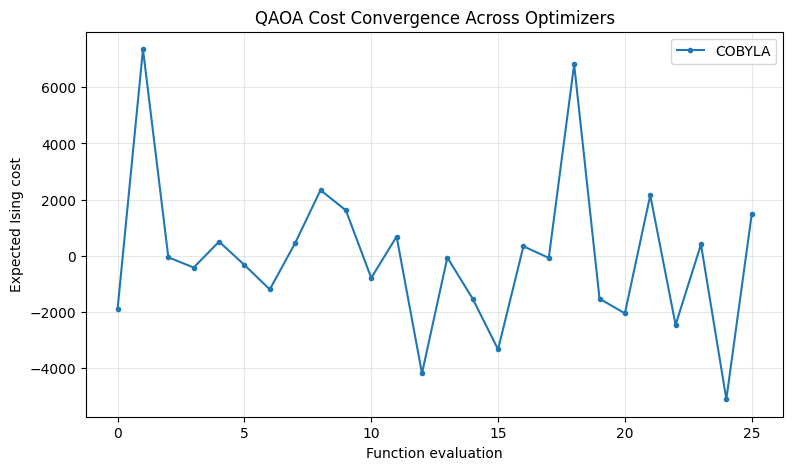

⏱️ Execution time: 0.3309 seconds


In [16]:

plt.figure(figsize=(9, 5))
for name, res in all_optimizer_runs.items():
    plt.plot(res["history"], marker="o", linewidth=1.5, markersize=3, label=name)

plt.title("QAOA Cost Convergence Across Optimizers")
plt.xlabel("Function evaluation")
plt.ylabel("Expected Ising cost")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 7) Sample from the best solver

In [18]:

qc = build_qaoa_circuit(best_params[0], best_params[1])
qc.measure_all()

simulator = AerSimulator()
shots = 4000

job = simulator.run(qc, shots=shots)
counts = job.result().get_counts()

print("Top measured bitstrings:")
for bitstring, count in sorted(counts.items(), key=lambda kv: kv[1], reverse=True)[:10]:
    print(bitstring, count)


Top measured bitstrings:
00011101111000100 7
10011000100100010 5
10111000110100011 5
11001001000011000 5
10100100111010011 4
11000101000100000 4
00010000110110111 4
11000101001001000 4
00001100101110001 4
01011011010001011 4
⏱️ Execution time: 0.1216 seconds


## 8) Decode the best feasible sampled solution

We evaluate the **full QUBO value** for each sampled bitstring, but the final business result is reported using:
- selected companies
- total allocation
- expected upside value in ₹


In [20]:

best_string = None
best_value = np.inf
all_values = []

for bitstring, count in counts.items():
    trimmed = bitstring[-num_total_vars:].zfill(num_total_vars)

    try:
        # reverse so index 0 corresponds to x0
        full_x = np.array([int(b) for b in reversed(trimmed)], dtype=int)
        if full_x.shape[0] != linear.shape[0]:
            continue

        value = float(full_x @ qubo_matrix @ full_x + linear @ full_x + constant)

        portfolio_bits = full_x[:n]
        slack_bits = full_x[n:]

        slack_value_units = int(np.dot(slack_bits, slack_weights)) if m > 0 else 0
        total_alloc = int(np.dot(portfolio_bits, allocations_rupees))
        total_upside_value = float(np.dot(portfolio_bits, upside_values_rupees))
        total_upside_percent_sum = float(np.dot(portfolio_bits, df["Upside %"].to_numpy()))

        feasible = (total_alloc <= budget)

        all_values.append({
            "bitstring_full": trimmed,
            "portfolio_bits": "".join(str(int(b)) for b in portfolio_bits[::-1]),
            "qubo_value": value,
            "count": int(count),
            "allocation": total_alloc,
            "upside_value": total_upside_value,
            "upside_percent_sum": total_upside_percent_sum,
            "slack_value_units": slack_value_units,
            "feasible": feasible,
        })

        if feasible and value < best_value:
            best_value = value
            best_string = portfolio_bits.copy()

    except Exception:
        continue

selected = []
total_alloc = 0
total_upside_percent_sum = 0.0
total_upside_value = 0.0

if best_string is not None:
    for i, b in enumerate(best_string):
        if b == 1:
            selected.append(df.loc[i, "Company"])
            total_alloc += int(df.loc[i, "Allocation (₹)"])
            total_upside_percent_sum += float(df.loc[i, "Upside %"])
            total_upside_value += float(df.loc[i, "Allocation (₹)"] * df.loc[i, "Upside %"] / 100.0)

best_portfolio_bitstring = "".join(str(int(b)) for b in best_string[::-1]) if best_string is not None else None

print("Selected companies:", selected)
print("Total allocation (₹):", total_alloc)
print("Sum of upside percentages:", total_upside_percent_sum)
print("Expected upside value (₹):", total_upside_value)
print("Best portfolio bitstring:", best_portfolio_bitstring)
print("Best QUBO value:", best_value)


Selected companies: ['INFOSYS', 'MINDTREE', 'BHARTI AIRTEL', 'SANATHAN TEXTILES', 'FUSION FINANCE', 'Quera']
Total allocation (₹): 800000
Sum of upside percentages: 45.0
Expected upside value (₹): 56900.0
Best portfolio bitstring: 010011101010
Best QUBO value: -52000.0
⏱️ Execution time: 0.4124 seconds


In [21]:

all_values_df = pd.DataFrame(all_values).sort_values(
    by=["feasible", "qubo_value", "count"],
    ascending=[False, True, False]
).reset_index(drop=True)

display(all_values_df.head(10))


,bitstring_full,portfolio_bits,qubo_value,count,allocation,upside_value,upside_percent_sum,slack_value_units,feasible
0,00111010011101010,010011101010,-52000.0,1,800000,56900.0,45.0,7,True
1,00100010011100010,010011100010,-48800.0,1,620000,48800.0,40.5,4,True
2,00111010111110000,010111110000,-46700.0,1,770000,50300.0,40.5,7,True
3,00001010101110010,010101110010,-46400.0,1,780000,46400.0,35.5,1,True
4,00010001111100000,001111100000,-45700.0,1,660000,45800.0,36.5,2,True
5,01001001011100010,001011100010,-45200.0,1,660000,48800.0,39.5,9,True
6,00001110001100010,110001100010,-45150.0,1,780000,45150.0,32.0,1,True
7,00001010111100000,010111100000,-44900.0,1,620000,45800.0,37.5,1,True
8,00111010111100000,010111100000,-44900.0,1,620000,45800.0,37.5,7,True
9,00001100111100000,100111100000,-43950.0,1,710000,44050.0,35.0,1,True


⏱️ Execution time: 0.0634 seconds


## 9) Classical brute-force check on the portfolio bits only

This checks the true optimum over all `2^n` possible company subsets and lets you compare QAOA against the exact classical best answer.


In [23]:

best_classical_bits = None
best_classical_upside = -float("inf")
best_classical_alloc = None

for bits in product([0, 1], repeat=n):
    x = np.array(bits, dtype=int)
    total_alloc_candidate = int(np.dot(x, allocations_rupees))

    if total_alloc_candidate <= budget:
        total_upside_candidate = float(np.dot(x, upside_values_rupees))
        if total_upside_candidate > best_classical_upside:
            best_classical_upside = total_upside_candidate
            best_classical_bits = x.copy()
            best_classical_alloc = total_alloc_candidate

classical_selected = [df.loc[i, "Company"] for i in range(n) if best_classical_bits[i] == 1]
classical_bitstring = "".join(str(int(b)) for b in best_classical_bits[::-1])

print("Classical optimal portfolio:", classical_selected)
print(f"Total Allocation: ₹{best_classical_alloc:,.0f}")
print(f"Expected Upside Value: ₹{best_classical_upside:,.1f}")
print("Classical bitstring:", classical_bitstring)

if best_string is not None:
    qaoa_gap = best_classical_upside - total_upside_value
    print(f"QAOA sampled solution gap from classical optimum: ₹{qaoa_gap:,.1f}")


Classical optimal portfolio: ['INFOSYS', 'MINDTREE', 'BHARTI AIRTEL', 'SANATHAN TEXTILES', 'FUSION FINANCE', 'Quera']
Total Allocation: ₹800,000
Expected Upside Value: ₹56,900.0
Classical bitstring: 010011101010
QAOA sampled solution gap from classical optimum: ₹0.0
⏱️ Execution time: 0.0399 seconds


## 10) Notes

- The **QUBO value** is the internal optimization cost: objective + penalty.
- The **Expected Upside Value (₹)** is the real portfolio quantity that matters to you.
- To try 12 companies or more, keep the scaling idea and tune:
  - `scale`
  - `P`
  - `maxiter`
  - `shots`
